In [1]:
import pandas as pd
import snowflake.connector
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import joblib

In [2]:
load_dotenv()

conn = snowflake.connector.connect(
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA_TRANSFORMED"),
)

query = """
    SELECT * 
    FROM FACT_LOANS l
    LEFT JOIN DIM_FRED_MACRO_INDICATORS f
    ON l.LOAN_ISSUE_DATE = f.DATE
"""

df = pd.read_sql(query, conn)
dfbackup = df.copy()
conn.close()

C:\Users\bmass\AppData\Local\Temp\ipykernel_15068\3586255038.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
df = dfbackup

In [4]:
# Create Target Variable
df = df[df['LOAN_STATUS'].isin(['Fully Paid', 'Charged Off'])]
df['TARGET'] = (df['LOAN_STATUS'] == 'Charged Off').astype(int) # Charged Off = 1, Fully Paid = 0

C:\Users\bmass\AppData\Local\Temp\ipykernel_15068\3702445835.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TARGET'] = (df['LOAN_STATUS'] == 'Charged Off').astype(int) # Charged Off = 1, Fully Paid = 0


In [5]:
columns = df.columns.tolist()
for col in columns:
    pct = df[col].isnull().mean() * 100
    print(f"{col:45s} {pct:.2f}%")

LOAN_ID                                       0.00%
LOAN_STATUS                                   0.00%
LOAN_ISSUE_DATE                               0.00%
LOAN_AMOUNT                                   0.00%
LOAN_TERM                                     0.00%
LOAN_INTEREST_RATE                            0.00%
LOAN_INSTALLMENT                              0.00%
LOAN_PURPOSE                                  0.00%
LOAN_EMP_LENGTH                               5.84%
LOAN_HOME_OWNERSHIP                           0.00%
LOAN_ANNUAL_INCOME                            0.00%
LOAN_APPLICATION_TYPE                         0.00%
LOAN_ADDR_STATE                               0.00%
LOAN_DTI                                      0.03%
LOAN_FICO_RANGE_LOW                           0.00%
LOAN_FICO_RANGE_HIGH                          0.00%
LOAN_EARLIEST_CR_LINE                         0.00%
LOAN_OPEN_ACC                                 0.00%
LOAN_TOTAL_ACC                                0.00%
LOAN_REVOL_B

In [6]:
# Missing Value Analysis/Handling
columns = df.columns.tolist()
for col in columns:
    pct = df[col].isnull().mean() * 100
    print(f"{col:45s} {pct:.2f}%")

df['LOAN_PRIOR_DELINQUENCY'] = df['LOAN_MTHS_SINCE_LAST_DELINQ'].notnull().astype(int)
df['LOAN_PRIOR_RECORD'] = df['LOAN_MTHS_SINCE_LAST_RECORD'].notnull().astype(int)
df = df[df['LOAN_DTI'].notnull()]

zero_fill_cols = [
    'LOAN_EMP_LENGTH', 'LOAN_TOTAL_REV_HI_LIM', 'LOAN_TOT_COLL_AMT', 
    'LOAN_NUM_ACCTS_EVER_120_PD', 'LOAN_MORT_ACC'
]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

median_fill_cols = [
    'LOAN_TOT_CUR_BAL', 'LOAN_TOT_HI_CRED_LIM', 'LOAN_TOTAL_BAL_EX_MORT',
    'LOAN_TOTAL_BC_LIMIT', 'LOAN_AVG_CUR_BAL', 'LOAN_BC_UTIL',
    'LOAN_BC_OPEN_TO_BUY', 'LOAN_PERCENT_BC_GT_75', 'LOAN_PCT_TL_NVR_DLQ'
]
df[median_fill_cols] = df[median_fill_cols].fillna(df[median_fill_cols].median())

df = df.drop(columns=['LOAN_MTHS_SINCE_LAST_DELINQ', 'LOAN_MTHS_SINCE_LAST_RECORD', 'LOAN_REVOL_UTIL', 'LOAN_PUB_REC_BANKRUPTCIES'])

LOAN_ID                                       0.00%
LOAN_STATUS                                   0.00%
LOAN_ISSUE_DATE                               0.00%
LOAN_AMOUNT                                   0.00%
LOAN_TERM                                     0.00%
LOAN_INTEREST_RATE                            0.00%
LOAN_INSTALLMENT                              0.00%
LOAN_PURPOSE                                  0.00%
LOAN_EMP_LENGTH                               5.84%
LOAN_HOME_OWNERSHIP                           0.00%
LOAN_ANNUAL_INCOME                            0.00%
LOAN_APPLICATION_TYPE                         0.00%
LOAN_ADDR_STATE                               0.00%
LOAN_DTI                                      0.03%
LOAN_FICO_RANGE_LOW                           0.00%
LOAN_FICO_RANGE_HIGH                          0.00%
LOAN_EARLIEST_CR_LINE                         0.00%
LOAN_OPEN_ACC                                 0.00%
LOAN_TOTAL_ACC                                0.00%
LOAN_REVOL_B

C:\Users\bmass\AppData\Local\Temp\ipykernel_15068\968433530.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LOAN_PRIOR_DELINQUENCY'] = df['LOAN_MTHS_SINCE_LAST_DELINQ'].notnull().astype(int)
C:\Users\bmass\AppData\Local\Temp\ipykernel_15068\968433530.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LOAN_PRIOR_RECORD'] = df['LOAN_MTHS_SINCE_LAST_RECORD'].notnull().astype(int)


In [7]:
# Drop Columns Without Predictive Value
df = df.drop(columns=['LOAN_ID', 'LOAN_STATUS', 'LOAN_ISSUE_DATE', 'LOAN_ADDR_STATE', 'DATE'])

In [8]:
# Convert To Numeric Values
df['LOAN_TERM'] = df['LOAN_TERM'].str.split().str[0].astype(int)
df['LOAN_PURPOSE'] = (df['LOAN_PURPOSE'] == 'debt_consolidation').astype(int)
df['LOAN_EMP_LENGTH'] = df['LOAN_EMP_LENGTH'].astype(str).str.replace(r'[<>+]|years?', '', regex=True).str.strip().astype(int)
df['LOAN_HOME_OWNERSHIP'] = (df['LOAN_HOME_OWNERSHIP'] == 'OWN').astype(int)
df['LOAN_APPLICATION_TYPE'] = (df['LOAN_APPLICATION_TYPE'] == 'Individual').astype(int)
df['LOAN_EARLIEST_CR_LINE'] = df['LOAN_EARLIEST_CR_LINE'].str.split('-').str[1].astype(int)

df = df.rename(columns={
    'LOAN_TERM': 'LOAN_TERM_MONTHS', 
    'LOAN_PURPOSE': 'LOAN_PURPOSE_IS_DEBT_CONSOLIDATION', 
    'LOAN_HOME_OWNERSHIP': 'LOAN_OWNS_HOME',
    'LOAN_APPLICATION_TYPE': 'LOAN_APPLYING_AS_INDIVIDUAL',
    })

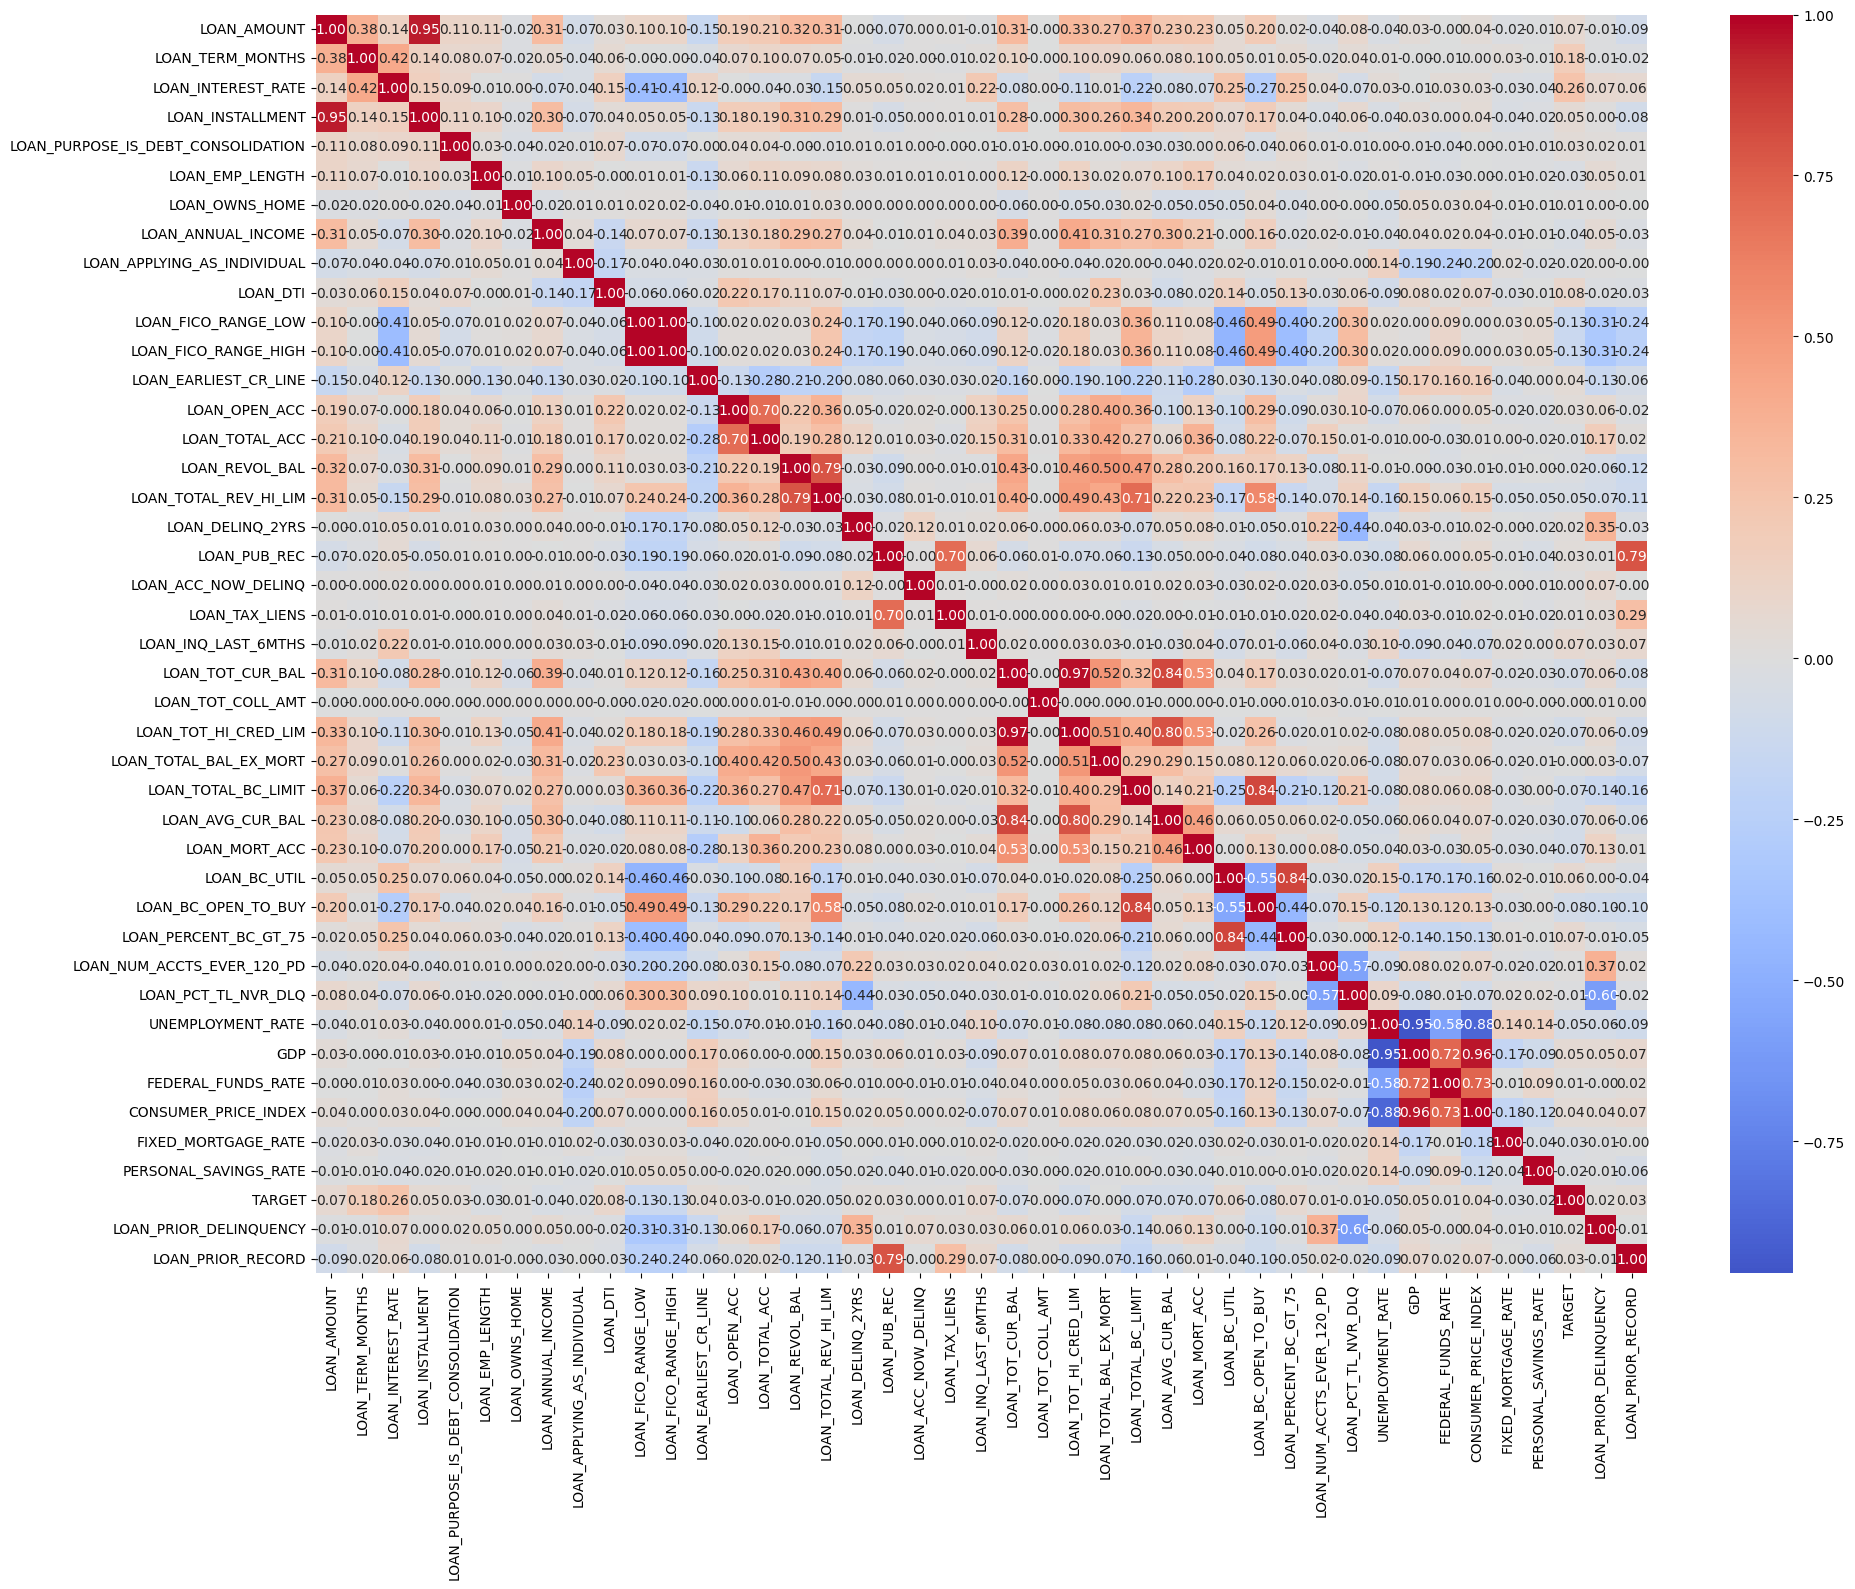

In [9]:
# Variable Correlation Matrix
corr = df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [10]:
# Drop Redundant Correlated Variables, Or Variables Not Correlated With TARGET
df = df.drop(columns=['LOAN_INSTALLMENT', 'LOAN_FICO_RANGE_HIGH', 'LOAN_TOT_CUR_BAL', 'LOAN_AVG_CUR_BAL', 'LOAN_BC_OPEN_TO_BUY', 'LOAN_PERCENT_BC_GT_75', 'LOAN_PCT_TL_NVR_DLQ', 'UNEMPLOYMENT_RATE', 'CONSUMER_PRICE_INDEX', 'LOAN_PUB_REC', 'LOAN_TOTAL_ACC', 'LOAN_REVOL_BAL', 'LOAN_TOTAL_REV_HI_LIM'])

In [11]:
columns = df.columns.tolist()
for col in columns:
    print(col + "\n")

LOAN_AMOUNT

LOAN_TERM_MONTHS

LOAN_INTEREST_RATE

LOAN_PURPOSE_IS_DEBT_CONSOLIDATION

LOAN_EMP_LENGTH

LOAN_OWNS_HOME

LOAN_ANNUAL_INCOME

LOAN_APPLYING_AS_INDIVIDUAL

LOAN_DTI

LOAN_FICO_RANGE_LOW

LOAN_EARLIEST_CR_LINE

LOAN_OPEN_ACC

LOAN_DELINQ_2YRS

LOAN_ACC_NOW_DELINQ

LOAN_TAX_LIENS

LOAN_INQ_LAST_6MTHS

LOAN_TOT_COLL_AMT

LOAN_TOT_HI_CRED_LIM

LOAN_TOTAL_BAL_EX_MORT

LOAN_TOTAL_BC_LIMIT

LOAN_MORT_ACC

LOAN_BC_UTIL

LOAN_NUM_ACCTS_EVER_120_PD

GDP

FEDERAL_FUNDS_RATE

FIXED_MORTGAGE_RATE

PERSONAL_SAVINGS_RATE

TARGET

LOAN_PRIOR_DELINQUENCY

LOAN_PRIOR_RECORD



[0]	validation_0-auc:0.70388
[50]	validation_0-auc:0.72533
[100]	validation_0-auc:0.72825
[150]	validation_0-auc:0.72935
[200]	validation_0-auc:0.72992
[250]	validation_0-auc:0.73045
[299]	validation_0-auc:0.73078


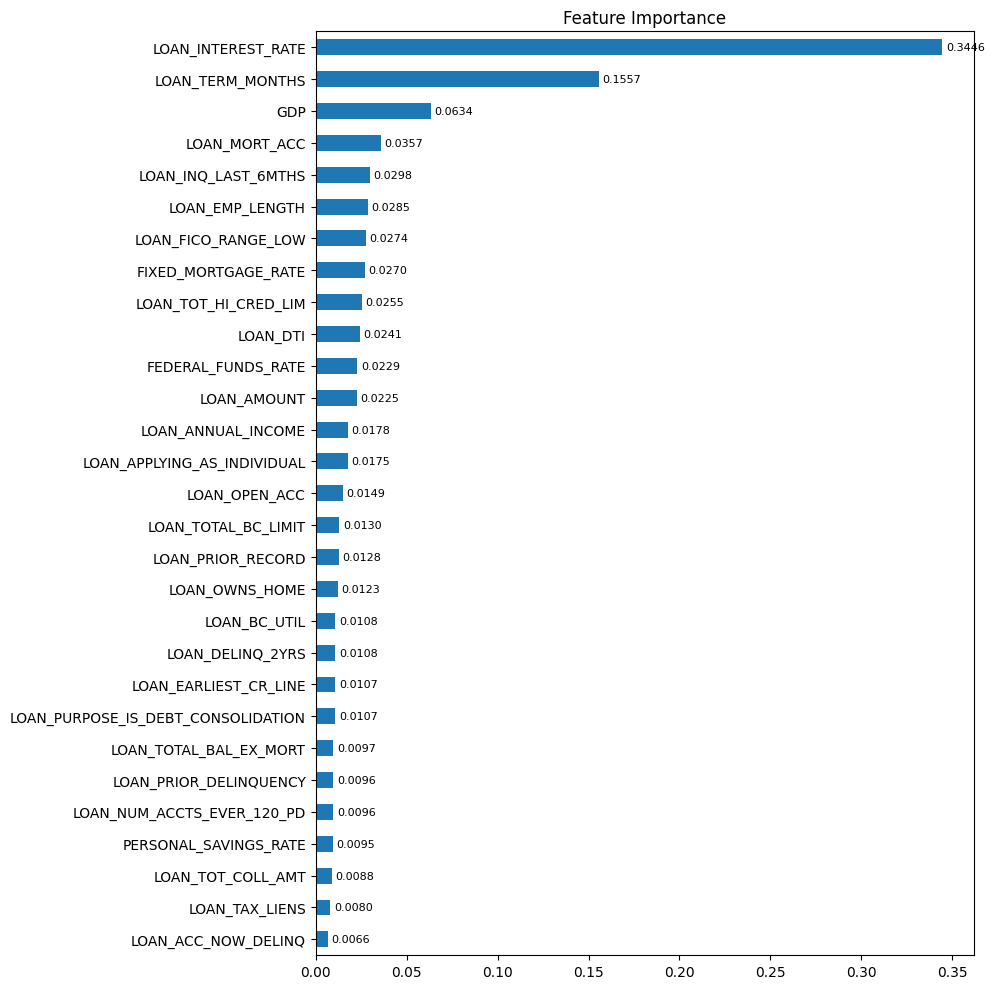

In [12]:
# Train XGBoost Model To Rank Feature Importance:

features = [
    'LOAN_AMOUNT', 'LOAN_TERM_MONTHS', 'LOAN_INTEREST_RATE',
    'LOAN_PURPOSE_IS_DEBT_CONSOLIDATION', 'LOAN_EMP_LENGTH', 'LOAN_OWNS_HOME',
    'LOAN_ANNUAL_INCOME', 'LOAN_APPLYING_AS_INDIVIDUAL', 'LOAN_DTI',
    'LOAN_FICO_RANGE_LOW', 'LOAN_EARLIEST_CR_LINE', 'LOAN_OPEN_ACC',
    'LOAN_DELINQ_2YRS', 'LOAN_ACC_NOW_DELINQ', 'LOAN_TAX_LIENS',
    'LOAN_INQ_LAST_6MTHS', 'LOAN_TOT_COLL_AMT', 'LOAN_TOT_HI_CRED_LIM',
    'LOAN_TOTAL_BAL_EX_MORT', 'LOAN_TOTAL_BC_LIMIT', 'LOAN_MORT_ACC',
    'LOAN_BC_UTIL', 'LOAN_NUM_ACCTS_EVER_120_PD', 'GDP',
    'FEDERAL_FUNDS_RATE', 'FIXED_MORTGAGE_RATE', 'PERSONAL_SAVINGS_RATE',
    'LOAN_PRIOR_DELINQUENCY', 'LOAN_PRIOR_RECORD'
]

X = df[features].fillna(-1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

importance = pd.Series(model.feature_importances_, index=features)

fig, ax = plt.subplots(figsize=(10, 10))
sorted_importance = importance.sort_values(ascending=True)
sorted_importance.plot(kind='barh', ax=ax)

for i, v in enumerate(sorted_importance):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [13]:
# To Simplify User Input, Exclude Non-FRED features with Importance < .01
features = [
    'LOAN_AMOUNT', 
    'LOAN_TERM_MONTHS', 
    'LOAN_INTEREST_RATE',
    'LOAN_PURPOSE_IS_DEBT_CONSOLIDATION', 
    'LOAN_EMP_LENGTH', 
    'LOAN_OWNS_HOME',
    'LOAN_ANNUAL_INCOME', 
    'LOAN_APPLYING_AS_INDIVIDUAL', 
    'LOAN_DTI',
    'LOAN_FICO_RANGE_LOW', 
    'LOAN_EARLIEST_CR_LINE', 
    'LOAN_OPEN_ACC',
    'LOAN_DELINQ_2YRS',
    'LOAN_INQ_LAST_6MTHS', 
    'LOAN_TOT_HI_CRED_LIM',
    'LOAN_TOTAL_BC_LIMIT', 
    'LOAN_MORT_ACC',
    'LOAN_BC_UTIL', 
    'GDP',
    'FEDERAL_FUNDS_RATE', 
    'FIXED_MORTGAGE_RATE', 
    'PERSONAL_SAVINGS_RATE',
    'LOAN_PRIOR_DELINQUENCY', 
    'LOAN_PRIOR_RECORD'
]

# Train Model
X = df[features].fillna(-1)
y = df['TARGET']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_train, X_eval, y_train, y_eval = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose=50
)

[0]	validation_0-auc:0.70546
[50]	validation_0-auc:0.72645
[100]	validation_0-auc:0.72908
[150]	validation_0-auc:0.73018
[200]	validation_0-auc:0.73075
[250]	validation_0-auc:0.73108
[299]	validation_0-auc:0.73137


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    107645
           1       0.33      0.67      0.44     26849

    accuracy                           0.66    134494
   macro avg       0.61      0.67      0.60    134494
weighted avg       0.78      0.66      0.69    134494

ROC AUC: 0.7294
[[70902 36743]
 [ 8797 18052]]


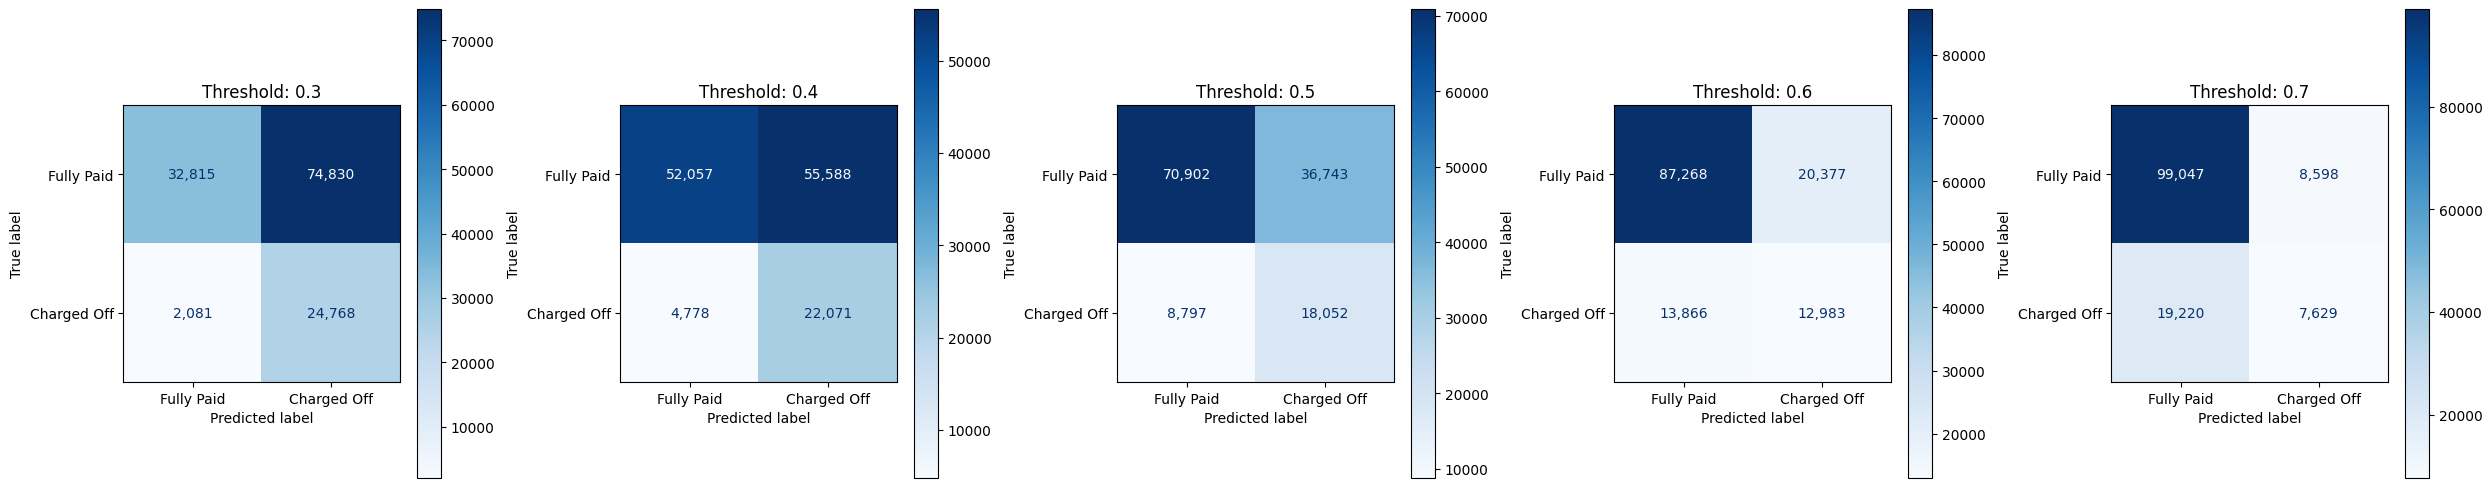

In [14]:
# Model Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(confusion_matrix(y_test, y_pred))

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, t in enumerate([0.3, 0.4, 0.5, 0.6, 0.7]):
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Charged Off'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'Threshold: {t:.1f}')

plt.tight_layout()
plt.show()

# A threshold of 0.6 establishes that a loan must be predicted >= 60 percent likely to charge off to deny
# This minimizes false negatives (Accepting a loan that gets charged off, which is costly) without an unreasonable amount
# of false positives (Denying a loan that would have been fully paid)

In [15]:
# Save Model

#joblib.dump(model, 'ml/model.pkl')
#joblib.dump({
#    'threshold': 0.6,
#    'features': features
#}, 'ml/model_config.pkl')